# CE444: Homework 2
Brandon Auyeung

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import string
import numpy as np
import scipy.integrate as intr
import scipy.stats as stats
from sympy import Symbol
import sympy as sp
import great_tables as gt

## Part 1

based on...


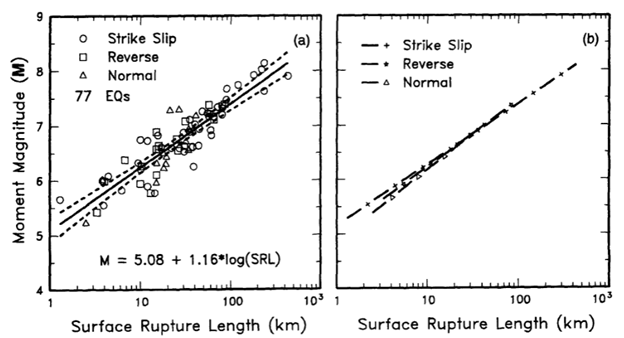

Eqn to graph:
$$ M_w =  5.08 +1.16log(SRL)$$



C:\Users\bahea\AppData\Local\Temp\ipykernel_22924\2053397962.py:16: RuntimeWarning: divide by zero encountered in log10
  M_model = a * np.log10(srl) + b


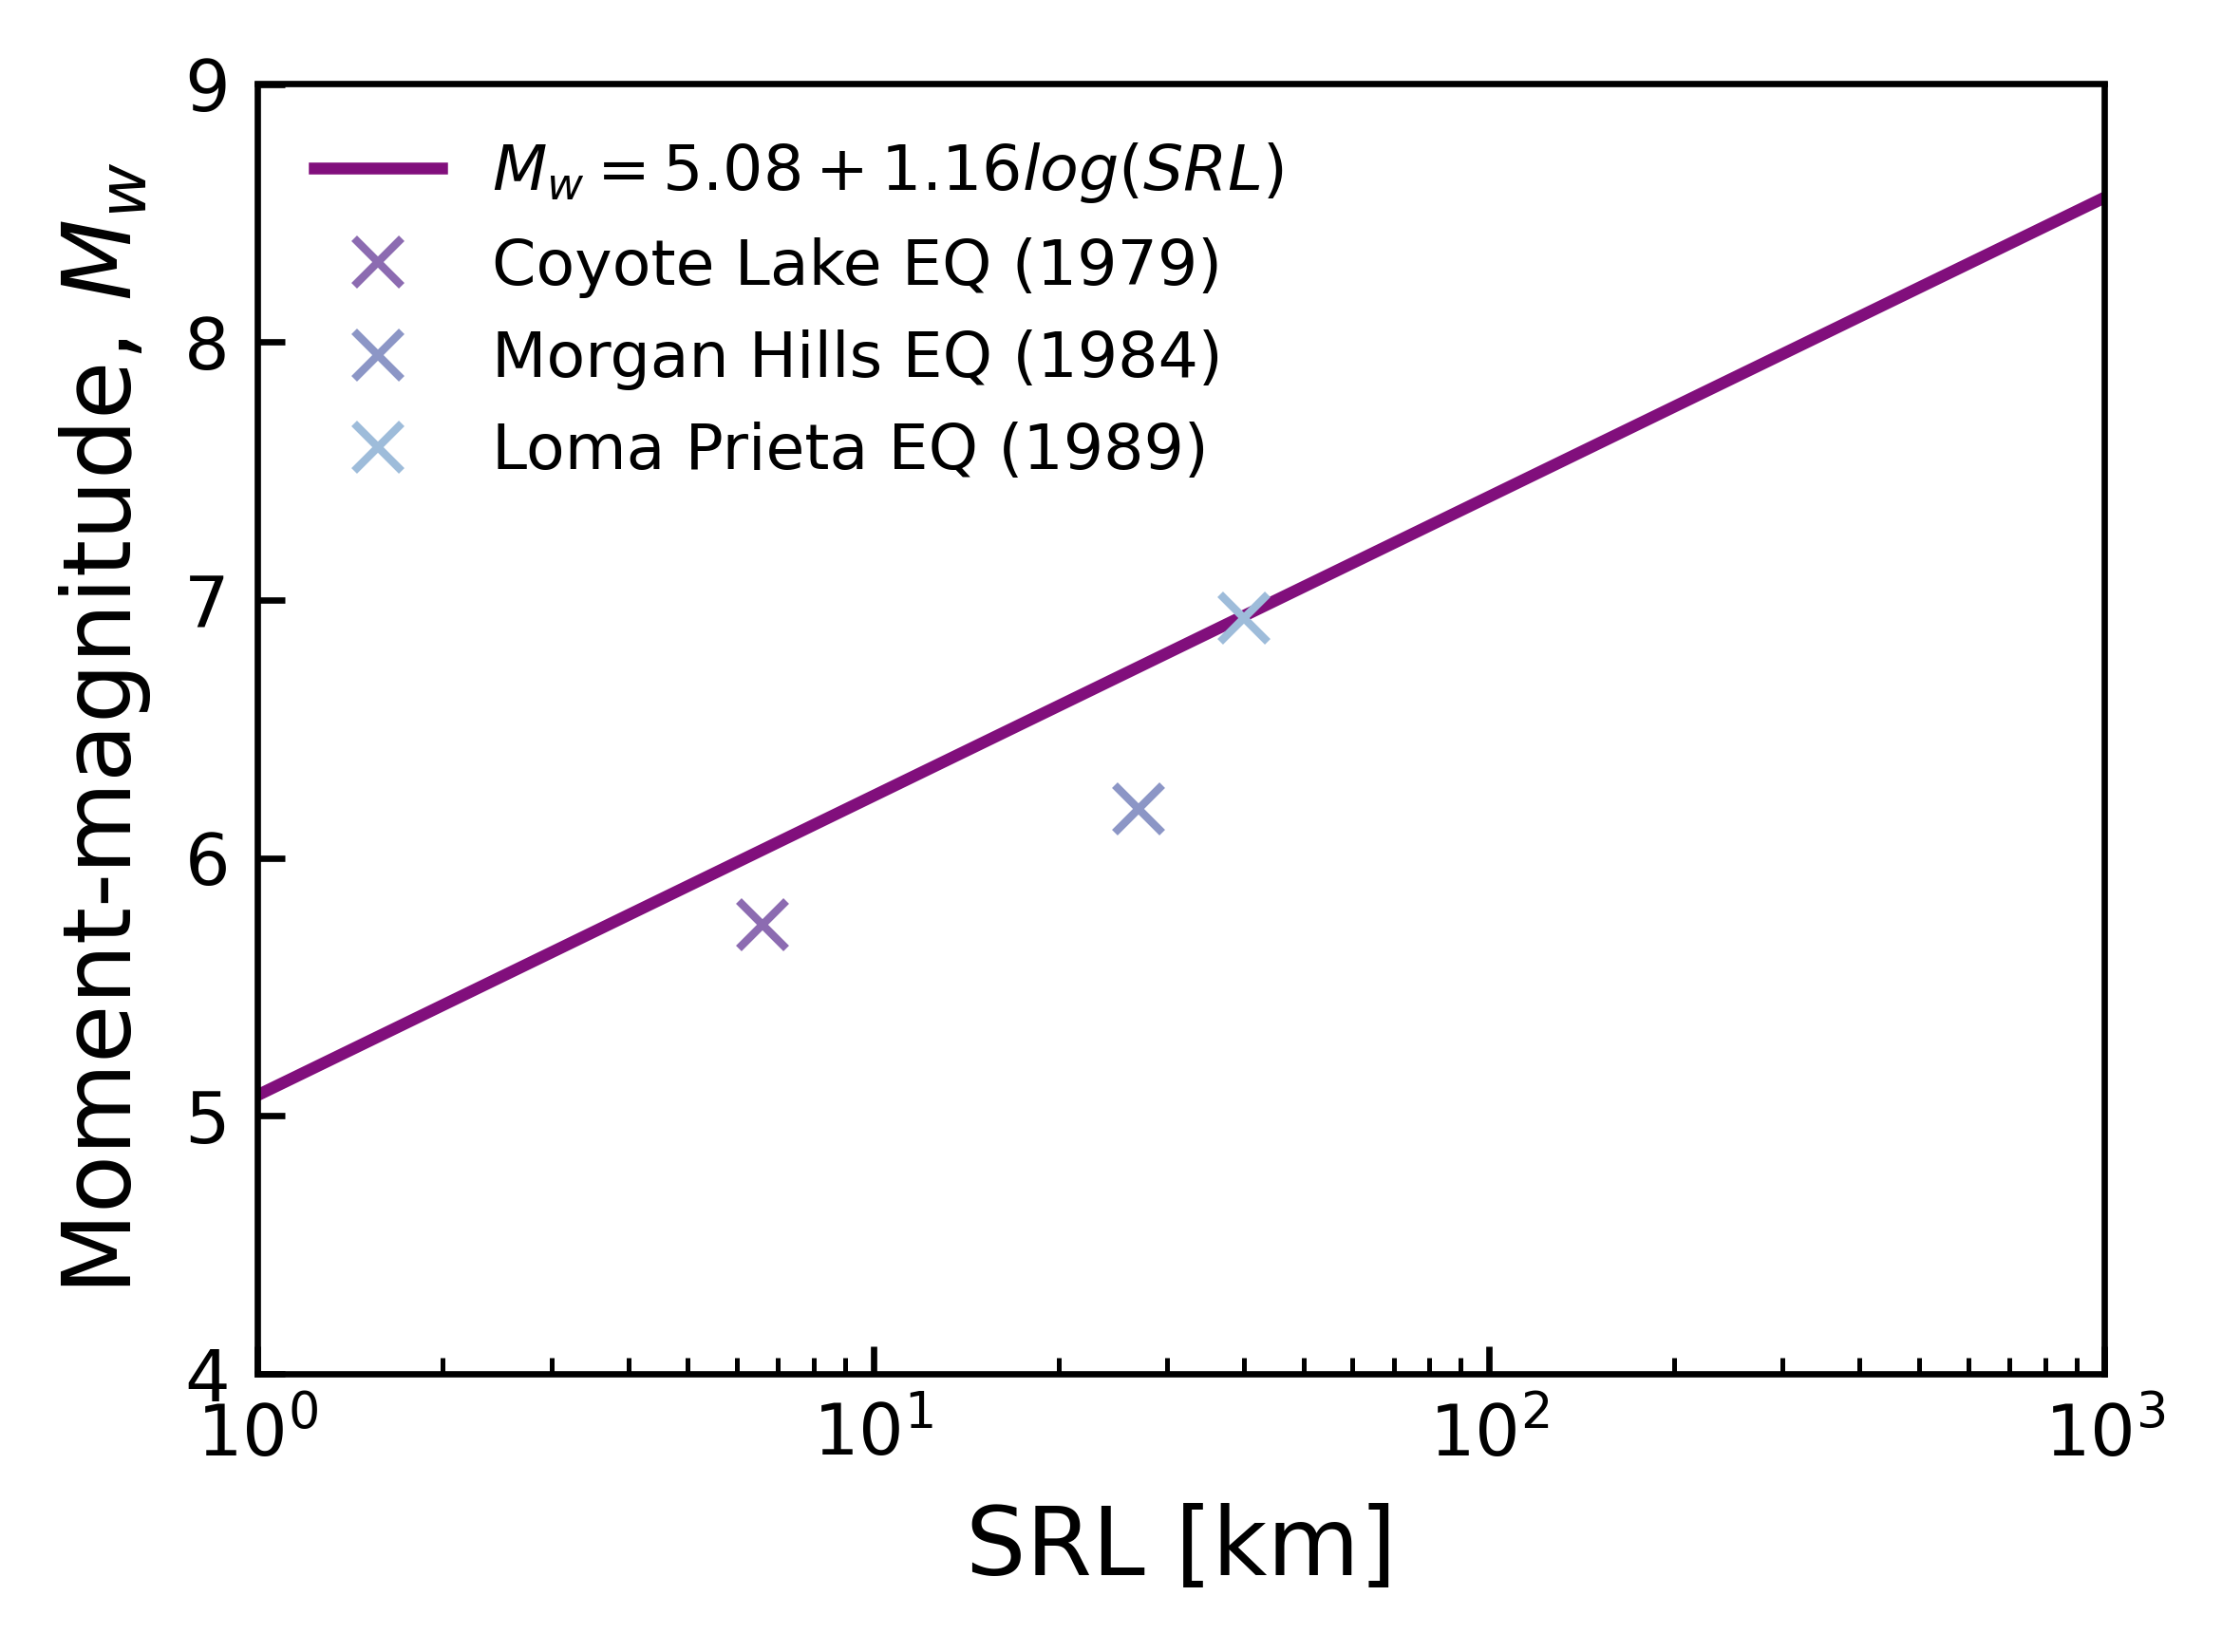

In [2]:
srl = np.linspace(0, 1000, 1000) # create SRL range in km

# model parameters
a = 1.16
b = 5.08

# GEER data
coyote_srl = 6.6 # srl in km for Coyote Lake 
coyote_M = 5.74 # moment magnitude for Coyote Lake
morgan_srl = 27 # srl in km for Morgan Hills
morgan_M = 6.19 # moment magnitude for Morgan Hills
loma_srl = 40 # srl in km for Loma Prieta
loma_M = 6.93 # moment magnitude for Loma Prieta

# calculate y values based on model
M_model = a * np.log10(srl) + b


# plot SRL vs M
afig, ax = subplots(figsize=(4, 3), tight_layout=True, dpi=600)
ax.semilogx(srl, M_model, color="#810F7C", label="$M_w = 5.08 + 1.16log(SRL)$")
ax.set_xlabel("SRL [km]", fontsize=12)
ax.set_ylabel("Moment-magnitude, $M_w$", fontsize=12)
ax.tick_params(axis='both', which='both', direction='in', labelsize=9)
ax.plot(coyote_srl, coyote_M, 'x', color="#8C6BB1", label="Coyote Lake EQ (1979)")
ax.plot(morgan_srl, morgan_M, 'x', color="#8C96C6", label="Morgan Hills EQ (1984)")
ax.plot(loma_srl, loma_M, 'x', color="#9EBCDA", label="Loma Prieta EQ (1989)")
plt.xlim(1, 1000)
plt.ylim(4, 9)
ax.legend(loc="best", fontsize=8, frameon=False)

## Part 2

In [5]:
# collect data that i already filtered out (contains Coyote Lake, Morgan Hills, and Loma Prieta)
filtered_EQ_data = pd.read_excel("Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx", sheet_name="filtered")
filtered_EQ_data

,Record Sequence Number,EQID,Earthquake Name,YEAR,MODY,HRMN,Station Name,Station Sequence Number,Station ID No.,Earthquake Magnitude,...,Instrument Nat. Freq.,Instrument Damping,Instrument Type,Quality_Flag,Spectra Quality Flag,Late S-trigger,Late P-trigger,Idirectivity,Tp,Ry 2
0,146,48,Coyote Lake,1979,806,1705,Gilroy Array #1,424,47379,5.74,...,-999,-999,-999,-999,0,-999,?,0,-999.000,-5.586326
1,147,48,Coyote Lake,1979,806,1705,Gilroy Array #2,425,47380,5.74,...,-999,-999,-999,-999,0,-999,?,1,1.463,-5.251018
2,455,90,Morgan Hill,1984,424,2115,Gilroy Array #1,424,47379,6.19,...,-999,-999,-999,-999,0,-999,?,0,-999.000,24.207436
3,456,90,Morgan Hill,1984,424,2115,Gilroy Array #2,425,47380,6.19,...,-999,-999,-999,-999,0,-999,?,0,-999.000,24.109490
4,765,118,Loma Prieta,1989,1018,5,Gilroy Array #1,424,47379,6.93,...,-999,-999,-999,-999,0,-999,?,0,-999.000,26.408614
5,766,118,Loma Prieta,1989,1018,5,Gilroy Array #2,425,47380,6.93,...,-999,-999,-999,-999,0,-999,?,1,1.729,26.907282


Collect the PGA and PGV per EQ

In [6]:
pga_v_data = pd.DataFrame(filtered_EQ_data, columns=["Earthquake Name", "Station Name","PGA (g)", "PGV (cm/sec)"])
pga_v_data.columns = ["Earthquake", "Station","PGA [g]", "PGV [cm/s]"]
# pga_v_data

pga_v_Table = gt.GT(pga_v_data).cols_align(
    "center").tab_options(
        table_font_names = gt.system_fonts("neo-grotesque")).tab_style(
            style = gt.style.text(size ="16px"), locations=gt.loc.body()
        )

pga_v_Table

Earthquake,Station,PGA [g],PGV [cm/s]
Coyote Lake,Gilroy Array #1,0.10589,7.649
Coyote Lake,Gilroy Array #2,0.24761,24.335
Morgan Hill,Gilroy Array #1,0.077057,2.7458
Morgan Hill,Gilroy Array #2,0.17395,9.0354
Loma Prieta,Gilroy Array #1,0.43322,32.699
Loma Prieta,Gilroy Array #2,0.35685,38.096


How does site effect impact PGA and PGV readings? Recall G1 is a rock site, whereas G2 is a soil site.

In [7]:
print(pga_v_data)
pga_v_data_plotting = pga_v_data.sort_values(by="Station", inplace=False) # separate data by station (rock site vs soil site)
pga_v_data_plotting["Soil Site"] = np.zeros(6)
pga_v_data_plotting["EQ Flag"] = np.zeros(6)

for i in range(6):
    if pga_v_data_plotting["Station"][i] == "Gilroy Array #1":
        pga_v_data_plotting.loc[i, "Soil Site"] = 0 # rock site
    else:
        pga_v_data_plotting.loc[i, "Soil Site"] = 1 # soil site

for i in range(6):
    if pga_v_data_plotting["Earthquake"][i] == "Coyote Lake":
        pga_v_data_plotting.loc[i, "EQ Flag"] = 0 # Coyote Lake
    elif pga_v_data_plotting["Earthquake"][i] == "Morgan Hill":
        pga_v_data_plotting.loc[i, "EQ Flag"] = 1 # Morgan Hill
    else:
        pga_v_data_plotting.loc[i, "EQ Flag"] = 2 # Loma Prieta

print(pga_v_data_plotting)

    Earthquake          Station   PGA [g]  PGV [cm/s]
0  Coyote Lake  Gilroy Array #1  0.105890      7.6490
1  Coyote Lake  Gilroy Array #2  0.247610     24.3350
2  Morgan Hill  Gilroy Array #1  0.077057      2.7458
3  Morgan Hill  Gilroy Array #2  0.173950      9.0354
4  Loma Prieta  Gilroy Array #1  0.433220     32.6990
5  Loma Prieta  Gilroy Array #2  0.356850     38.0960
    Earthquake          Station   PGA [g]  PGV [cm/s]  Soil Site  EQ Flag
0  Coyote Lake  Gilroy Array #1  0.105890      7.6490        0.0      0.0
2  Morgan Hill  Gilroy Array #1  0.077057      2.7458        0.0      1.0
4  Loma Prieta  Gilroy Array #1  0.433220     32.6990        0.0      2.0
1  Coyote Lake  Gilroy Array #2  0.247610     24.3350        1.0      0.0
3  Morgan Hill  Gilroy Array #2  0.173950      9.0354        1.0      1.0
5  Loma Prieta  Gilroy Array #2  0.356850     38.0960        1.0      2.0


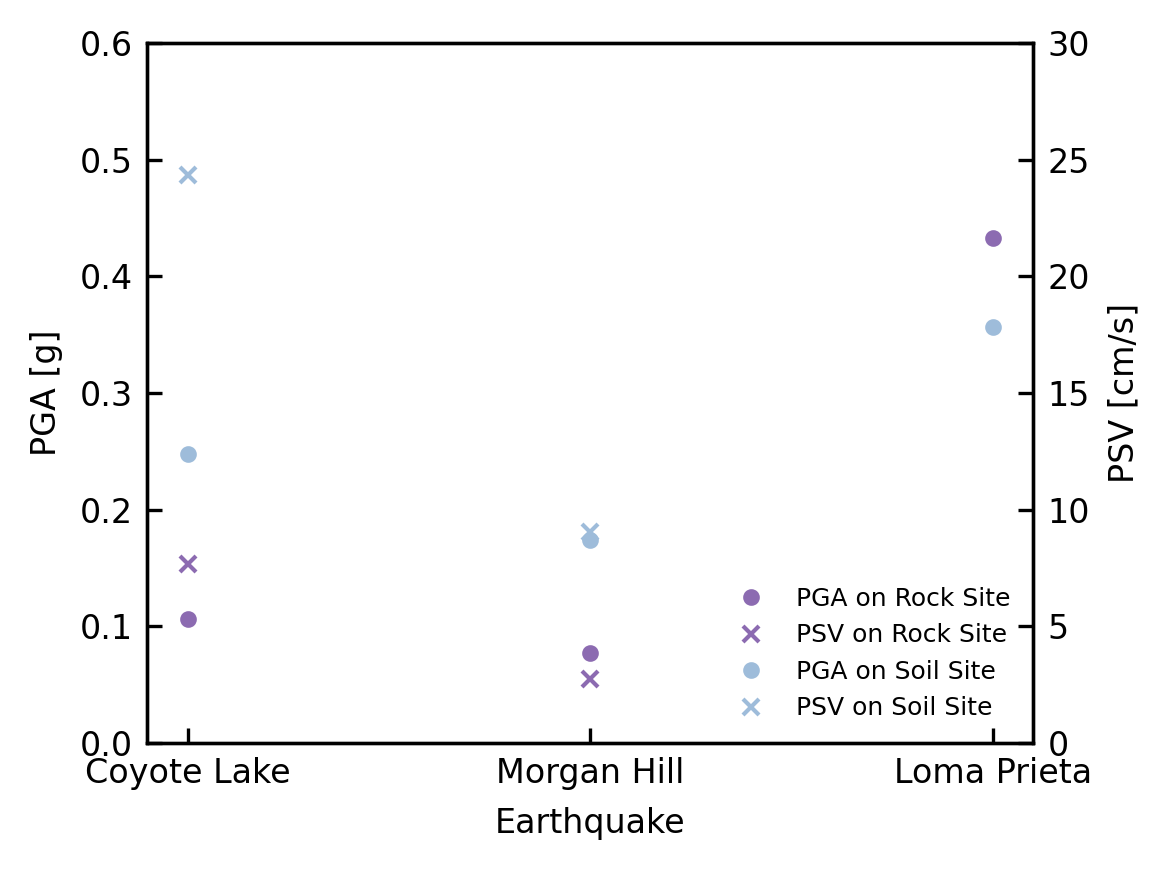

In [8]:
fig, ax_PGA = subplots(figsize=(4, 3), tight_layout=True, dpi=300)
ax_PGV = ax_PGA.twinx() # create PGA and PSV y axes

# plot data and name for legend
l1 = ax_PGA.plot(pga_v_data_plotting["EQ Flag"][0:3], pga_v_data_plotting["PGA [g]"][0:3], 'o', markersize=3,  color="#8C6BB1", label="PGA on Rock Site")
l2 = ax_PGV.plot(pga_v_data_plotting["EQ Flag"][0:3], pga_v_data_plotting["PGV [cm/s]"][0:3], 'x', markersize=4, color="#8C6BB1", label="PSV on Rock Site")
l3 = ax_PGA.plot(pga_v_data_plotting["EQ Flag"][3:6], pga_v_data_plotting["PGA [g]"][3:6], 'o', markersize=3, color="#9EBCDA", label="PGA on Soil Site")
l4 = ax_PGV.plot(pga_v_data_plotting["EQ Flag"][3:6], pga_v_data_plotting["PGV [cm/s]"][3:6], 'x', markersize=4, color="#9EBCDA", label="PSV on Soil Site")

# create legend
label_list = l1+l2+l3+l4
sep_labels = [l.get_label() for l in label_list] 
plt.legend(label_list, sep_labels,loc="best", fontsize=6, frameon=False)

# rename x axis ticks to EQs
plt.xticks([0, 1, 2], ["Coyote Lake", "Morgan Hill", "Loma Prieta"], fontsize=8)

# format axes
ax_PGA.set_xlabel("Earthquake", fontsize=8)
ax_PGA.set_ylabel("PGA [g]", fontsize=8)
ax_PGV.set_ylabel("PSV [cm/s]", fontsize=8)
ax_PGA.set_ylim(0, 0.6)
ax_PGV.set_ylim(0, 30)

ax_PGA.tick_params(axis='both', which='major', direction = "in", labelsize=8)
ax_PGV.tick_params(axis='both', which='major', direction = "in", labelsize=8)

plt.show()

The above figure is not gonna be turned in. Let's do something else.    

    Earthquake          Station   PGA [g]  PGV [cm/s]
0  Coyote Lake  Gilroy Array #1  0.105890      7.6490
1  Coyote Lake  Gilroy Array #2  0.247610     24.3350
2  Morgan Hill  Gilroy Array #1  0.077057      2.7458
3  Morgan Hill  Gilroy Array #2  0.173950      9.0354
4  Loma Prieta  Gilroy Array #1  0.433220     32.6990
5  Loma Prieta  Gilroy Array #2  0.356850     38.0960
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20.]


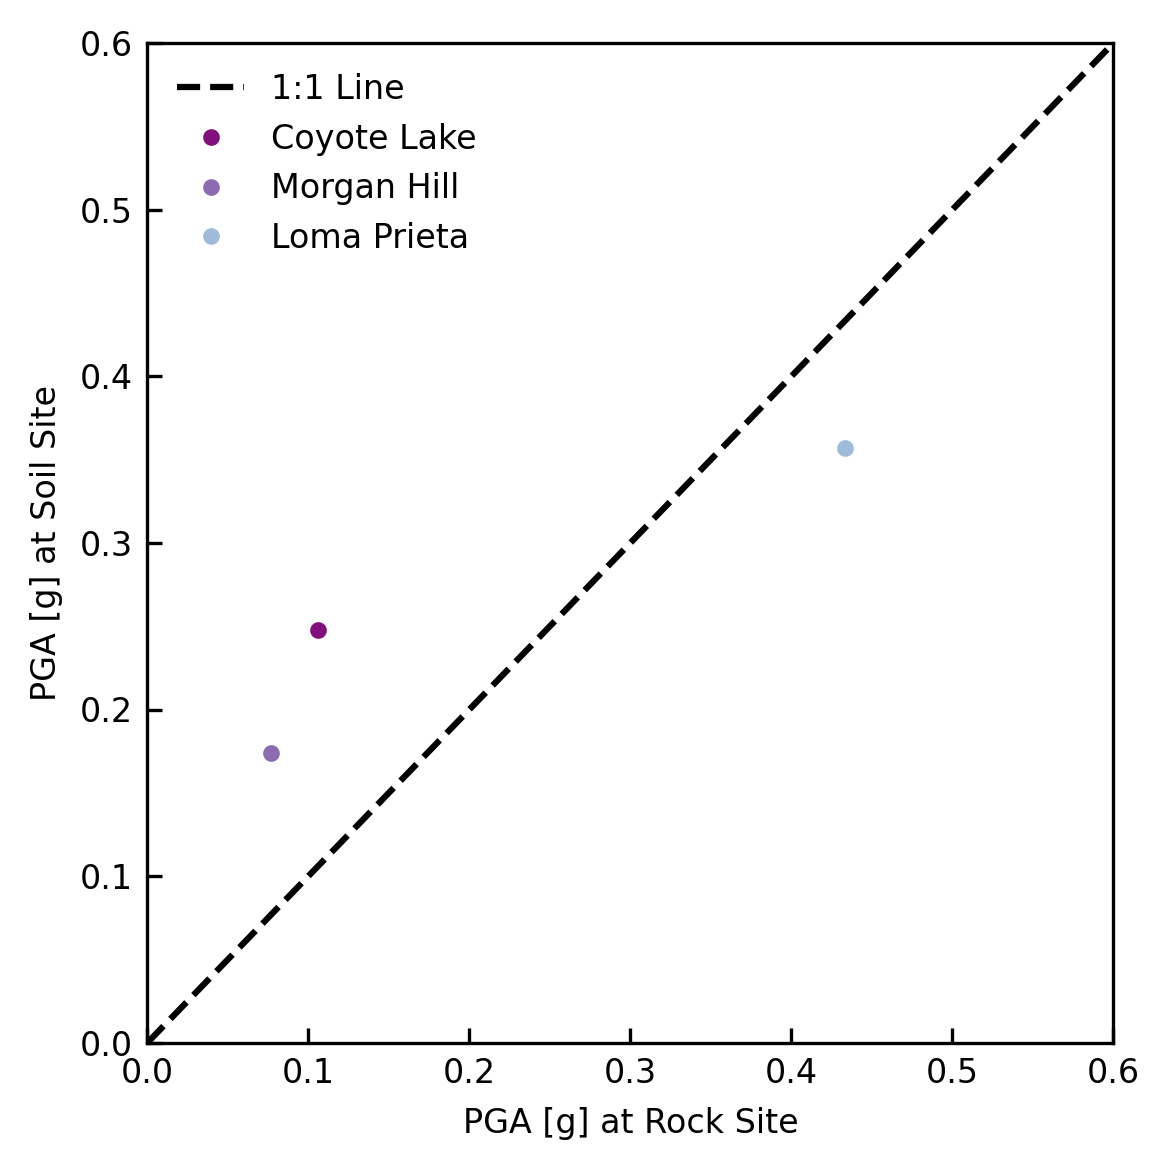

In [9]:
print(pga_v_data)
one_to_one = np.linspace(0,20,21)
print(one_to_one)

fig, ax = subplots(figsize=(4, 4), tight_layout=True, dpi=300)

ax.plot(one_to_one, one_to_one, color="black", linestyle="--", label="1:1 Line")
ax.plot(pga_v_data["PGA [g]"][0], pga_v_data["PGA [g]"][1], 'o', markersize=3, color="#810f7c", label="Coyote Lake")
ax.plot(pga_v_data["PGA [g]"][2], pga_v_data["PGA [g]"][3], 'o', markersize=3, color="#8c6bb1", label="Morgan Hill")
ax.plot(pga_v_data["PGA [g]"][4], pga_v_data["PGA [g]"][5], 'o', markersize=3, color="#9EBCDA", label="Loma Prieta")

ax.set_xlabel("PGA [g] at Rock Site", fontsize=8)
ax.set_ylabel("PGA [g] at Soil Site", fontsize=8)
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)

ax.tick_params(axis='both', which='major', direction = "in", labelsize=8)

plt.legend(fontsize=8, frameon=False)

    Earthquake          Station   PGA [g]  PGV [cm/s]
0  Coyote Lake  Gilroy Array #1  0.105890      7.6490
1  Coyote Lake  Gilroy Array #2  0.247610     24.3350
2  Morgan Hill  Gilroy Array #1  0.077057      2.7458
3  Morgan Hill  Gilroy Array #2  0.173950      9.0354
4  Loma Prieta  Gilroy Array #1  0.433220     32.6990
5  Loma Prieta  Gilroy Array #2  0.356850     38.0960
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40.]


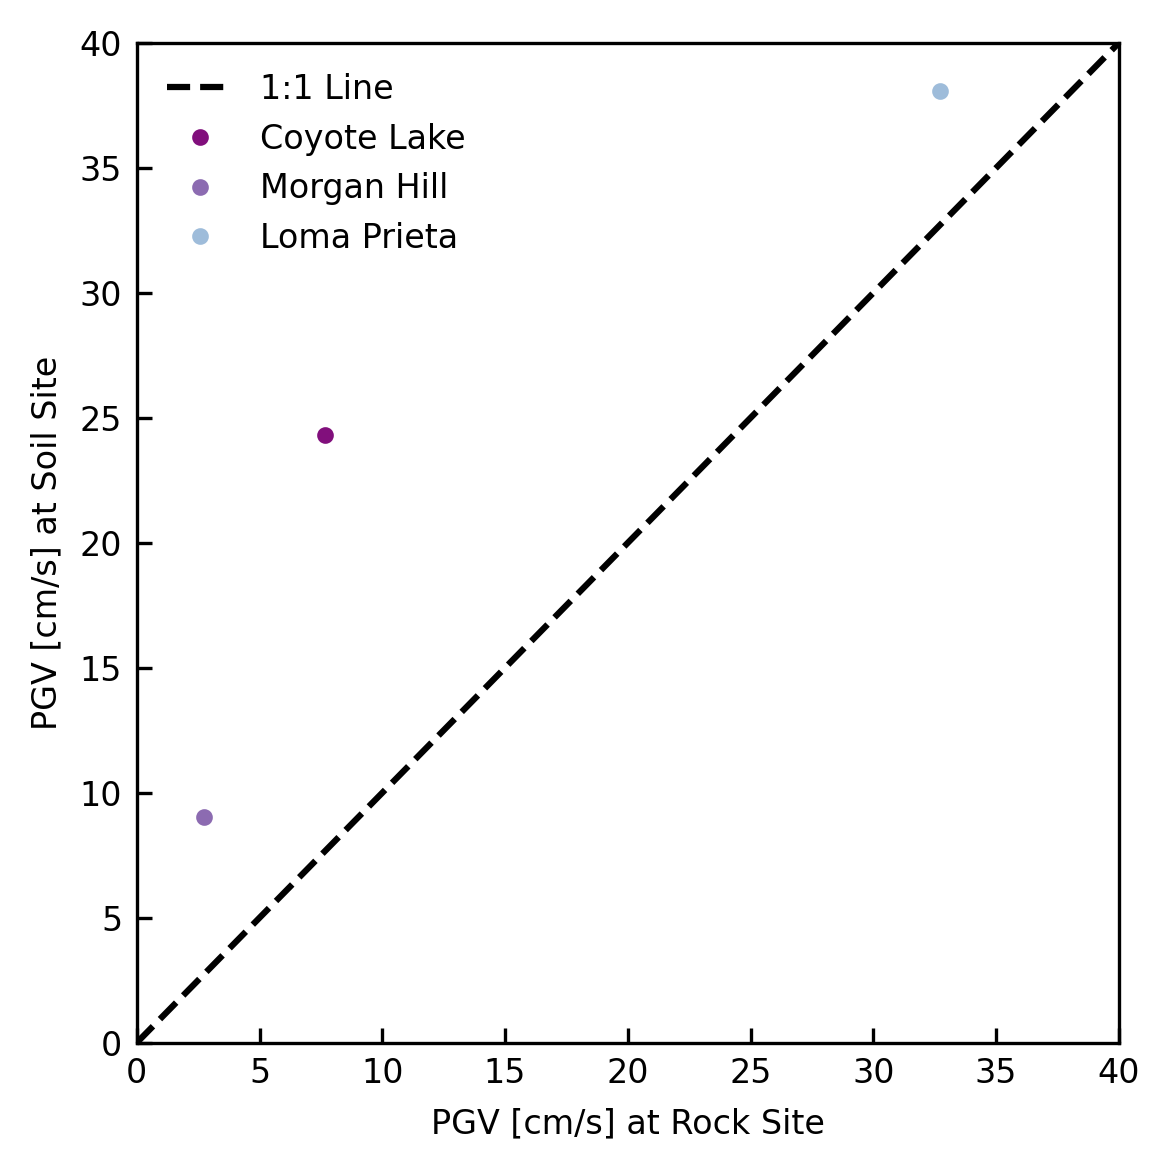

In [12]:
print(pga_v_data)
one_to_one = np.linspace(0,40,41)
print(one_to_one)

fig, ax = subplots(figsize=(4, 4), tight_layout=True, dpi=300)

ax.plot(one_to_one, one_to_one, color="black", linestyle="--", label="1:1 Line")
ax.plot(pga_v_data["PGV [cm/s]"][0], pga_v_data["PGV [cm/s]"][1], 'o', markersize=3, color="#810f7c", label="Coyote Lake")
ax.plot(pga_v_data["PGV [cm/s]"][2], pga_v_data["PGV [cm/s]"][3], 'o', markersize=3, color="#8c6bb1", label="Morgan Hill")
ax.plot(pga_v_data["PGV [cm/s]"][4], pga_v_data["PGV [cm/s]"][5], 'o', markersize=3, color="#9EBCDA", label="Loma Prieta")

ax.set_xlabel("PGV [cm/s] at Rock Site", fontsize=8)
ax.set_ylabel("PGV [cm/s] at Soil Site", fontsize=8)
ax.set_xlim(0, 40)
ax.set_ylim(0, 40)

ax.tick_params(axis='both', which='major', direction = "in", labelsize=8)

plt.legend(fontsize=8, frameon=False)

Part 3

Clean and filter all data that is relavent to the spectra 

In [13]:
# print(filtered_EQ_data.columns.get_loc("T0.010S")) # where does the spectra data start?
# print(filtered_EQ_data.columns.get_loc("T20.000S")) # where does the spectra data end?
amp_data = pd.DataFrame(filtered_EQ_data, columns=["Earthquake Name", "Station Name"])
spectra_data = amp_data.join(filtered_EQ_data.iloc[:, 134:244]) # add the EQ aned Station data with the spectra data
# print(spectra_data.columns[2:] )
spectra_col_names = ["EQ", "Station"]
for index, col in enumerate(spectra_data.columns[2:]): # for each column that is part of the spectra data
    spectra_col_names.append(spectra_data.columns[2+index].removeprefix("T").removesuffix("S")) # remove the T and S

spectra_data.columns = spectra_col_names

for i in range(6):
    if spectra_data["EQ"][i] == "Coyote Lake":
        spectra_data.loc[i, "EQ"] = 0 # Coyote Lake EQ flag
    elif spectra_data["EQ"][i] == "Morgan Hill":
        spectra_data.loc[i, "EQ"] = 1 # Morgan Hill EQ flag
    else:
        spectra_data.loc[i, "EQ"] = 2 # Loma Prieta EQ flag

for i in range(6):
    if spectra_data["Station"][i] == "Gilroy Array #1":
        spectra_data.loc[i, "Station"] = 0 # Gilroy Array #1, Rock Site
    else:
        spectra_data.loc[i, "Station"] = 1 # Gilroy Array #2, Soil Site

spectra_data


,EQ,Station,0.010,0.020,0.022,0.025,0.029,0.030,0.032,0.035,...,8.000,8.500,9.000,9.500,10.000,11.000,12.000,13.000,14.000,15.000
0,0,0,0.107015,0.112627,0.112819,0.114576,0.124465,0.130651,0.145066,0.153106,...,0.001397,0.001198,0.001101,0.001013,0.000951,0.001009,0.000911,0.000702,0.000576,0.000484
1,0,1,0.247895,0.258362,0.263062,0.264814,0.263912,0.262629,0.258442,0.262997,...,0.003176,0.002784,0.002460,0.002188,0.001959,0.001596,0.001326,0.001119,0.000957,0.000828
2,1,0,0.077343,0.084820,0.085522,0.091446,0.089151,0.089719,0.097692,0.118499,...,0.001085,0.000868,0.000732,0.000623,0.000526,0.000395,0.000327,0.000269,0.000221,0.000183
3,1,1,0.173973,0.176858,0.177787,0.177201,0.178613,0.180773,0.183319,0.188927,...,0.001849,0.001366,0.001070,0.000943,0.000860,0.000711,0.000584,0.000477,0.000391,0.000337
4,2,0,0.437089,0.477591,0.479794,0.496725,0.526296,0.534072,0.534103,0.543660,...,0.009300,0.008176,0.007272,0.006693,0.006238,0.005277,0.004401,0.003713,0.003122,0.002600
5,2,1,0.356921,0.358833,0.359434,0.359078,0.362184,0.363360,0.364957,0.367181,...,0.009439,0.008338,0.007207,0.006687,0.006132,0.004960,0.004381,0.003776,0.003163,0.002598


Determine site amp ratios

In [14]:
coyote_site_ratio = spectra_data.iloc[1, 2:] / spectra_data.iloc[0, 2:] # determine the site ratio for the Coyote Lake EQ
# print(coyote_site_ratio)

morgan_site_ratio = spectra_data.iloc[3, 2:] / spectra_data.iloc[2, 2:] # determine the site ratio for the Morgan Hill EQ
# print(morgan_site_ratio)

loma_site_ratio = spectra_data.iloc[5, 2:] / spectra_data.iloc[4, 2:] # determine the site ratio for the Loma Prieta EQ
# print(loma_site_ratio)

Plot site amp ratios w.r.t. period

C:\Users\bahea\AppData\Local\Temp\ipykernel_22924\3949020579.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10)


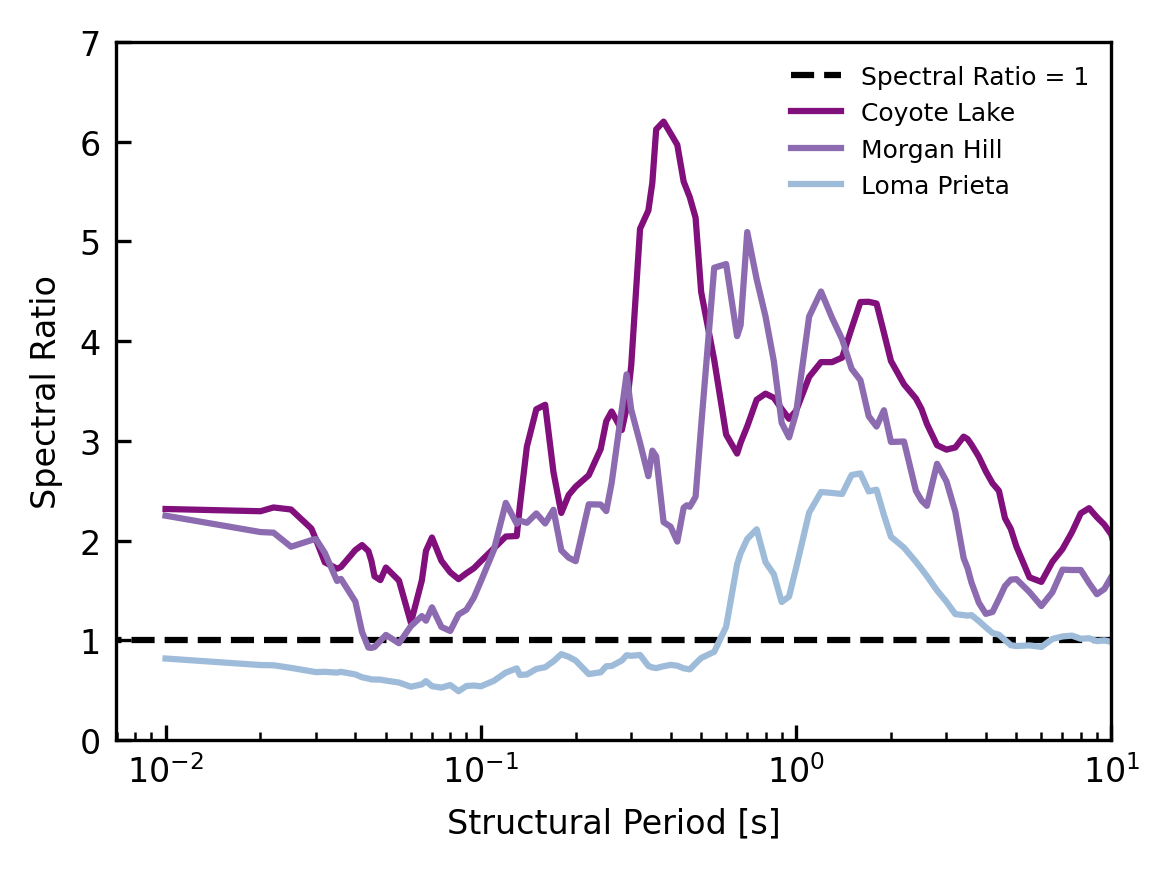

In [15]:
fig, ax = subplots(figsize=(4, 3), tight_layout=True, dpi=300)

# at hline = 1, soil has no amp or deamp effect
plt.hlines(y=1, xmin=0.00, xmax=10, color="black", linestyle="--", label="Spectral Ratio = 1")

# plot site ratios for EQs
#np.asarray(morgan_site_ratio.index.values, 'float') # convert index to float rather than string values
plt.semilogx(np.asarray(coyote_site_ratio.index.values, 'float'), coyote_site_ratio, color="#810f7c", label="Coyote Lake")
plt.semilogx(np.asarray(morgan_site_ratio.index.values, 'float'), morgan_site_ratio, color="#8c6bb1", label="Morgan Hill")
plt.semilogx(np.asarray(loma_site_ratio.index.values, 'float'), loma_site_ratio, color="#9ebcda", label="Loma Prieta")

plt.legend(loc="best", fontsize=6, frameon=False)

plt.xlabel("Structural Period [s]", fontsize=8)
plt.ylabel("Spectral Ratio", fontsize=8)

ax.tick_params(axis='both', which='both', direction = "in", labelsize=8)

ax.set_xlim(0, 10)
ax.set_ylim(0, 7)

plt.show()

Part d

$$ V = m S_a = \frac{W}{g} S_a$$

In [21]:
# the Sa is 0.05296458g

morgan_Sa = 0.08360343 * 9.81 # m/s^2
print(morgan_Sa)

# mass from weight
weight = 60 #kN
mass = weight / 9.81 # kg
print(mass)

# base shear
base_shear = morgan_Sa * mass
print(base_shear)

0.8201496483000001
6.116207951070336
5.016205800000001


$$S_d = \frac{S_a}{\omega_n^2} ; \omega_n = \frac{2\pi}{T}$$